# Phase 3: SoRad Pricing Engine

Demonstrates the SoRad (Solar Radiation Derivative) pricing formula (Eq. 19):

$$V_t = p_T \cdot V_{1,t} + (1-p_T) \cdot V_{0,t}$$

where each state price is:

$$\frac{V_{i,t}}{B(t,T)} = (K - C_T(1-\alpha)) \cdot \Phi\!\left(\frac{K_Y - M_i}{S_i}\right) + C_T \beta \cdot G_{i,0}(K_Y)$$

Under $\lambda^R = 0$, pricing measure $Q \approx P$.

**Sections:**
1. Load 2013 calibration
2. SoRad price for a single contract (2014-09-15 → 2014-09-16)
3. Strike sensitivity curve
4. Horizon sensitivity (1-day to 365-day prices)
5. Daily SoRad prices over the full year 2014

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from solarrpy.calibration import calibrate_window
from solarrpy.forecastDensity import (
    clearsky_at, seasonal_mean_Y_at, mixture_expected_R, conditional_moments_Y
)
from solarrpy.sorad import (
    strike_to_Y, daily_strike, G_integral, sorad_price
)

## 0. Load data and calibrate (2013 window)

In [ ]:
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()  # H0 is computed internally, and the provided values are not trustworthy

df_train = df[df['Year'] <= 2013].copy()

# Bologna Coordinates used in the paper
LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

print('Training data: 2005-01-01 to 2013-12-31 —', len(df_train), 'rows')

cal = calibrate_window(
    df_train,
    target_col='GHI',
    clearsky_col='clearsky',
    date_col='date',
    coords={'lat': LATITUDE},
    train_end_year=2013,
    optimiser='delta_optimiser',
)
print(f'θ = {cal.theta:.4f},  α = {cal.alpha:.4f},  β = {cal.beta:.4f}')
print(f'a = {cal.a}')
print()
print('Monthly mixture parameters:')
print(cal.monthly_mixture[['Month', 'p', 'mu1', 'sd1', 'mu0', 'sd0']].to_string(index=False))

Training data: 2005-01-01 to 2013-12-31 — 3287 rows
θ = 0.9214,  α = 0.0042,  β = 0.9187
a = [-0.065524   -0.07077706 -0.39356608]

Monthly mixture parameters:
 Month        p       mu1      sd1      mu0      sd0
     1 0.472923 -0.157419 0.965827 0.064431 0.824892
     2 0.533785 -0.434248 1.248871 0.711213 0.336316
     3 0.378903 -0.755022 1.217377 0.504609 0.508494
     4 0.443198 -0.712779 1.069588 0.482352 0.410263
     5 0.443114 -0.617145 1.134051 0.410440 0.408486
     6 0.417603 -0.722004 1.286181 0.304312 0.447117
     7 0.341168 -0.445649 1.125165 0.444052 0.363524
     8 0.362408 -0.617428 1.407907 0.496977 0.354533
     9 0.393964 -0.606447 1.283621 0.498586 0.392253
    10 0.467828 -0.749178 1.154212 0.512504 0.497986
    11 0.526310 -0.259694 1.083706 0.014285 0.971152
    12 0.518030 -0.423857 0.957179 0.610034 0.586943


## 1. Single SoRad contract: 2014-09-15 → 2014-09-16

In [3]:
T_NOW  = '2014-09-15'
T_1DAY = '2014-09-16'

R_t    = float(df.loc[df['date'] == T_NOW, 'GHI'].iloc[0])
R_real = float(df.loc[df['date'] == T_1DAY, 'GHI'].iloc[0])

K_n    = daily_strike(T_1DAY, cal)
C_T    = clearsky_at(T_1DAY, cal)

print(f'Conditioning: R_t = {R_t:.4f} kWh/m²  at {T_NOW}')
print(f'Realized:     R_T = {R_real:.4f} kWh/m²  at {T_1DAY}')
print(f'Clear-sky:    C_T = {C_T:.4f} kWh/m²')
print(f'Daily strike: K_n = {K_n:.4f} kWh/m²')
print(f'Strike Y:     K_Y = {strike_to_Y(K_n, T_1DAY, cal):.4f}')
print()

mom = conditional_moments_Y(R_t, T_NOW, T_1DAY, cal)
print(f'Conditional moments (Y-space):')
print(f'  State 1 (cloudy): M1 = {mom["mu1"]:.4f}, S1 = {np.sqrt(mom["var1"]):.4f}')
print(f'  State 0 (sunny):  M0 = {mom["mu0"]:.4f}, S0 = {np.sqrt(mom["var0"]):.4f}')
print(f'  p_T (cloudy)    = {mom["p_T"]:.4f}')
print()

V = sorad_price(K_n, R_t, T_NOW, T_1DAY, cal)
E_R = mixture_expected_R(R_t, T_NOW, T_1DAY, cal)
payoff = max(K_n - R_real, 0.0)

print(f'SoRad price:     V_t  = {V:.4f} kWh/m²')
print(f'Expected GHI:    E[R] = {E_R:.4f} kWh/m²')
print(f'Realized payoff: max(K-R_T, 0) = {payoff:.4f} kWh/m²')
print(f'In-the-money: {R_real < K_n}')

Conditioning: R_t = 5.2550 kWh/m²  at 2014-09-15
Realized:     R_T = 4.8885 kWh/m²  at 2014-09-16
Clear-sky:    C_T = 6.2148 kWh/m²
Daily strike: K_n = 4.3015 kWh/m²
Strike Y:     K_Y = 0.1018

Conditional moments (Y-space):
  State 1 (cloudy): M1 = -0.1326, S1 = 0.9117
  State 0 (sunny):  M0 = 0.6259, S0 = 0.2786
  p_T (cloudy)    = 0.3940

SoRad price:     V_t  = 0.3538 kWh/m²
Expected GHI:    E[R] = 4.6892 kWh/m²
Realized payoff: max(K-R_T, 0) = 0.0000 kWh/m²
In-the-money: False


## 2. Strike sensitivity curve

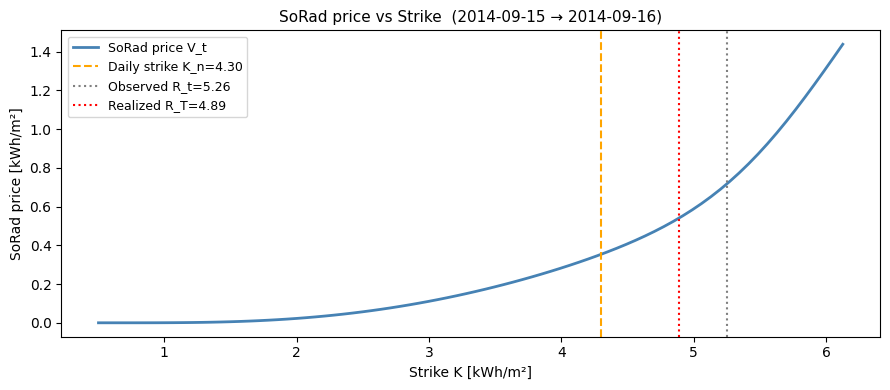

Saved Figure3a_sorad_strike.png


In [4]:
alpha, beta = cal.alpha, cal.beta
R_min = C_T * (1.0 - alpha - beta) * 1.05
R_max = C_T * (1.0 - alpha) * 0.99
K_grid = np.linspace(R_min, R_max, 80)

prices = [sorad_price(K, R_t, T_NOW, T_1DAY, cal) for K in K_grid]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_grid, prices, color='steelblue', lw=2, label='SoRad price V_t')
ax.axvline(K_n,    color='orange', ls='--', lw=1.5, label=f'Daily strike K_n={K_n:.2f}')
ax.axvline(R_t,    color='gray',   ls=':',  lw=1.5, label=f'Observed R_t={R_t:.2f}')
ax.axvline(R_real, color='red',    ls=':',  lw=1.5, label=f'Realized R_T={R_real:.2f}')
ax.set_xlabel('Strike K [kWh/m²]')
ax.set_ylabel('SoRad price [kWh/m²]')
ax.set_title(f'SoRad price vs Strike  ({T_NOW} → {T_1DAY})', fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig('../results/Figure3a_sorad_strike.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure3a_sorad_strike.png')

## 3. Horizon sensitivity: V_t as a function of forecast horizon

 horizon        K        V
       1 4.301529 0.353834
       2 4.247329 0.427067
       3 4.193130 0.451347
       4 4.138953 0.457967
       5 4.084816 0.458344
       6 4.030738 0.456356
       7 3.976736 0.453420
       8 3.922830 0.450073
       9 3.869039 0.446524
      10 3.815380 0.442857
...
 horizon        K        V
     345 5.407115 0.492641
     350 5.153750 0.484052
     355 4.892524 0.502740
     360 4.625733 0.490817
     365 4.355714 0.476725


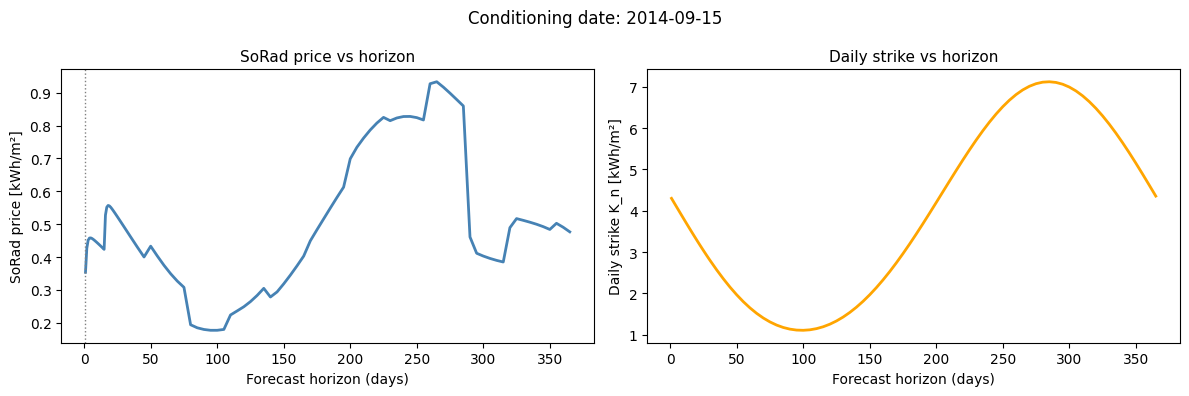

Saved Figure3b_sorad_horizon.png


In [5]:
horizons = list(range(1, 31)) + list(range(30, 366, 5))
t_start  = pd.Timestamp(T_NOW)

horizon_prices = []
for h in horizons:
    t_hor = t_start + pd.Timedelta(days=h)
    K_h   = daily_strike(t_hor, cal)
    V_h   = sorad_price(K_h, R_t, T_NOW, str(t_hor.date()), cal)
    horizon_prices.append({'horizon': h, 'K': K_h, 'V': V_h})

hp = pd.DataFrame(horizon_prices)
print(hp[['horizon', 'K', 'V']].head(10).to_string(index=False))
print('...')
print(hp[['horizon', 'K', 'V']].tail(5).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hp['horizon'], hp['V'], color='steelblue', lw=2)
axes[0].set_xlabel('Forecast horizon (days)')
axes[0].set_ylabel('SoRad price [kWh/m²]')
axes[0].set_title('SoRad price vs horizon', fontsize=11)
axes[0].axvline(1, color='gray', ls=':', lw=1)

axes[1].plot(hp['horizon'], hp['K'], color='orange', lw=2)
axes[1].set_xlabel('Forecast horizon (days)')
axes[1].set_ylabel('Daily strike K_n [kWh/m²]')
axes[1].set_title('Daily strike vs horizon', fontsize=11)

fig.suptitle(f'Conditioning date: {T_NOW}', fontsize=12)
fig.tight_layout()
plt.savefig('../results/Figure3b_sorad_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure3b_sorad_horizon.png')

## 4. Daily SoRad prices over 2014 (1-day horizon, ATM strike)

In [6]:
df_2014 = df[df['Year'] == 2014].copy().reset_index(drop=True)
# Need at least one previous-day observation to condition on
df_2013_last = df[df['date'] == '2013-12-31'].copy()

print(f'Computing daily SoRad prices for {len(df_2014)} days in 2014...')

records = []
for i, row in df_2014.iterrows():
    t_hor = row['date']
    t_now = t_hor - pd.Timedelta(days=1)

    prev = df[df['date'] == t_now]
    if len(prev) == 0:
        continue
    R_prev = float(prev['GHI'].iloc[0])

    K_n = daily_strike(t_hor, cal)
    V_n = sorad_price(K_n, R_prev, str(t_now.date()), str(t_hor.date()), cal)
    payoff_n = max(K_n - row['GHI'], 0.0)

    records.append({
        'date':    t_hor,
        'R_t_1':   R_prev,
        'R_T':     row['GHI'],
        'K_n':     K_n,
        'V_n':     V_n,
        'payoff':  payoff_n,
        'itm':     row['GHI'] < K_n,
    })

daily = pd.DataFrame(records)
print(f'Computed {len(daily)} contracts')
print()
print('Summary statistics:')
print(daily[['V_n', 'K_n', 'payoff']].describe().round(4))

Computing daily SoRad prices for 365 days in 2014...
Computed 365 contracts

Summary statistics:
            V_n       K_n    payoff
count  365.0000  365.0000  365.0000
mean     0.5308    3.9628    0.5874
std      0.3691    2.1378    1.0045
min      0.0842    1.1065    0.0000
25%      0.3045    1.8306    0.0000
50%      0.4374    3.8154    0.0000
75%      0.5945    6.0980    0.7754
max      2.7354    7.1238    5.2339


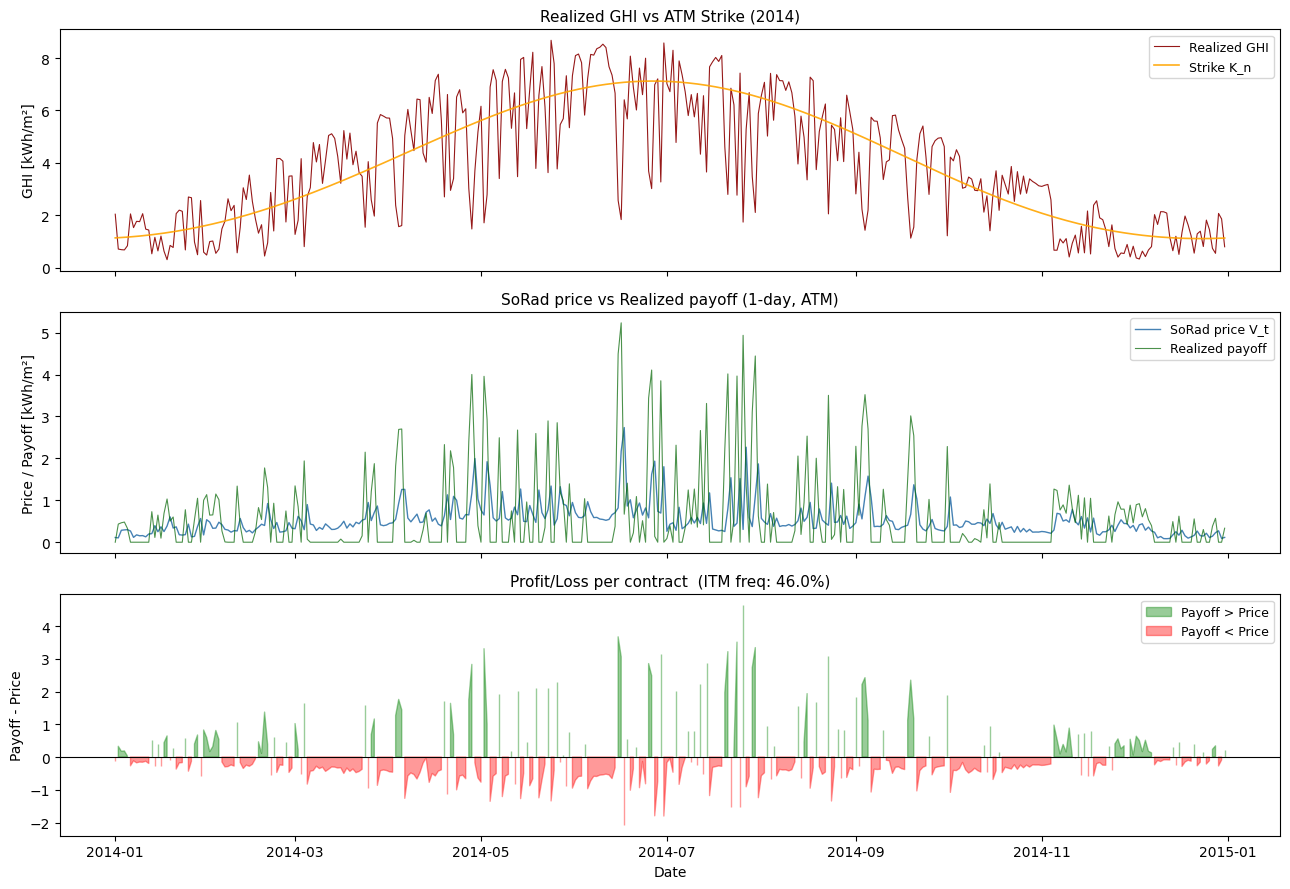

Saved Figure3c_sorad_daily2014.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].plot(daily['date'], daily['R_T'],   color='darkred',   lw=0.8, alpha=0.9, label='Realized GHI')
axes[0].plot(daily['date'], daily['K_n'],   color='orange',    lw=1.2, alpha=0.9, label='Strike K_n')
axes[0].set_ylabel('GHI [kWh/m²]')
axes[0].set_title('Realized GHI vs ATM Strike (2014)', fontsize=11)
axes[0].legend(fontsize=9)

axes[1].plot(daily['date'], daily['V_n'],    color='steelblue', lw=1.0, label='SoRad price V_t')
axes[1].plot(daily['date'], daily['payoff'], color='darkgreen', lw=0.8, alpha=0.7, label='Realized payoff')
axes[1].set_ylabel('Price / Payoff [kWh/m²]')
axes[1].set_title('SoRad price vs Realized payoff (1-day, ATM)', fontsize=11)
axes[1].legend(fontsize=9)

itm_frac = daily['itm'].mean()
axes[2].fill_between(daily['date'], daily['payoff'] - daily['V_n'],
                     0, where=(daily['payoff'] > daily['V_n']),
                     alpha=0.4, color='green', label='Payoff > Price')
axes[2].fill_between(daily['date'], daily['payoff'] - daily['V_n'],
                     0, where=(daily['payoff'] <= daily['V_n']),
                     alpha=0.4, color='red', label='Payoff < Price')
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_ylabel('Payoff - Price')
axes[2].set_title(f'Profit/Loss per contract  (ITM freq: {itm_frac:.1%})', fontsize=11)
axes[2].set_xlabel('Date')
axes[2].legend(fontsize=9)

fig.tight_layout()
plt.savefig('../results/Figure3c_sorad_daily2014.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figure3c_sorad_daily2014.png')

## 5. Phase 3 gate checks

In [8]:
# Gate 1: SoRad price is non-negative (put option)
assert daily['V_n'].min() >= 0.0, f'Negative price: {daily["V_n"].min():.4f}'
print('GATE PASS: All SoRad prices non-negative')

# Gate 2: Price is monotone in strike — test for September
sep_day = '2014-09-16'
R_cond  = float(df.loc[df['date'] == '2014-09-15', 'GHI'].iloc[0])
alpha, beta = cal.alpha, cal.beta
C_sep = clearsky_at(sep_day, cal)
strikes_test = np.linspace(C_sep*(1-alpha-beta)*1.1, C_sep*(1-alpha)*0.98, 10)
prices_test  = [sorad_price(K, R_cond, '2014-09-15', sep_day, cal) for K in strikes_test]
assert all(prices_test[i] <= prices_test[i+1] for i in range(len(prices_test)-1)), 'Not monotone'
print('GATE PASS: SoRad price monotone increasing in K')

# Gate 3: Invalid strike raises ValueError
try:
    sorad_price(100.0, R_t, T_NOW, T_1DAY, cal)
    assert False, 'Should have raised'
except ValueError:
    print('GATE PASS: ValueError raised for K above upper bound')

# Gate 4: K→ upper bound → price → C_T*(1-α) - E[R_T]
K_near_max = C_T * (1.0 - alpha) * 0.999
V_near_max  = sorad_price(K_near_max, R_t, T_NOW, T_1DAY, cal)
E_R_ref     = mixture_expected_R(R_t, T_NOW, T_1DAY, cal)
expected_at_max = K_near_max - E_R_ref
print(f'K→upper: V_t={V_near_max:.4f}, K-E[R]={expected_at_max:.4f}')
print('  (should be close — put price ≈ intrinsic value when deep ITM)')

print()
print('Phase 3 gate checks passed.')
print(f'Total 2014 SoRad prices: {len(daily)}')
print(f'Mean price:  {daily["V_n"].mean():.4f} kWh/m²')
print(f'Mean payoff: {daily["payoff"].mean():.4f} kWh/m²')
print(f'ITM freq:    {daily["itm"].mean():.1%}')

GATE PASS: All SoRad prices non-negative
GATE PASS: SoRad price monotone increasing in K
GATE PASS: ValueError raised for K above upper bound
K→upper: V_t=1.4930, K-E[R]=1.4930
  (should be close — put price ≈ intrinsic value when deep ITM)

Phase 3 gate checks passed.
Total 2014 SoRad prices: 365
Mean price:  0.5308 kWh/m²
Mean payoff: 0.5874 kWh/m²
ITM freq:    46.0%
